In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron as SklearnPerceptron

%matplotlib inline

# All the plots are saved here, so create the directory if it doesn't exist
os.makedirs("plots", exist_ok=True) 

# want bold titles/labels/legends on every plot, so just set it once globally
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42

In [10]:
columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
df = pd.read_csv("data_banknote_authentication.txt", header=None, names=columns)
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [11]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (1372, 5)


In [12]:
print("Missing values in the dataset:")
df.isnull().sum()   # check for missing values

Missing values in the dataset:


Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

In [13]:
print("Descriptive statistics of the dataset:")
df.describe()

Descriptive statistics of the dataset:


,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


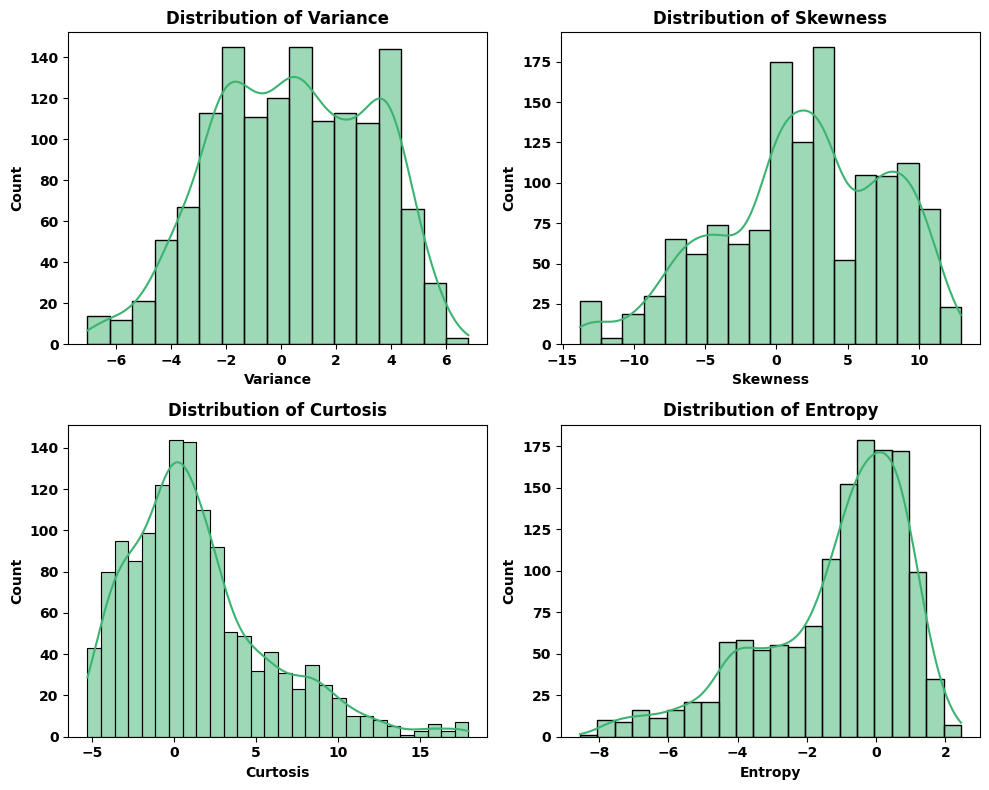

In [14]:
features = ["Variance", "Skewness", "Curtosis", "Entropy"]

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
sns.histplot(df["Variance"], kde=True, color="mediumseagreen")
plt.title("Distribution of Variance")

plt.subplot(2, 2, 2)
sns.histplot(df["Skewness"], kde=True, color="mediumseagreen")
plt.title("Distribution of Skewness")

plt.subplot(2, 2, 3)
sns.histplot(df["Curtosis"], kde=True, color="mediumseagreen")
plt.title("Distribution of Curtosis")

plt.subplot(2, 2, 4)
sns.histplot(df["Entropy"], kde=True, color="mediumseagreen")
plt.title("Distribution of Entropy")

plt.tight_layout()
plt.savefig("plots/histograms.png", dpi=600, bbox_inches="tight")
plt.show()

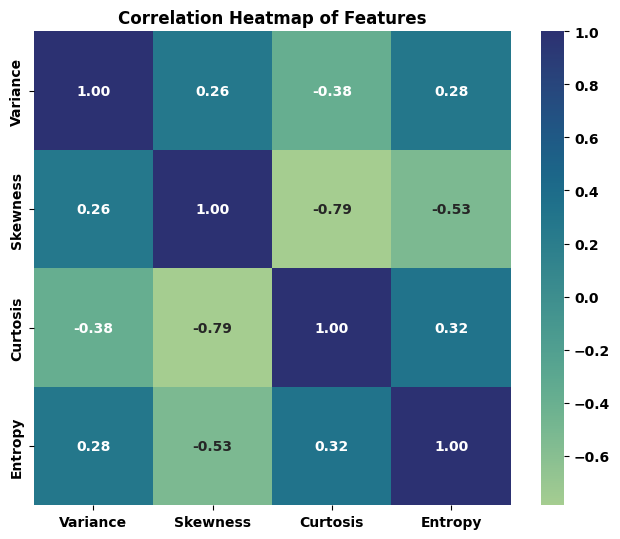

In [15]:
plt.figure(figsize=(6.5, 5.5))
corr_matrix = df[features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="crest")
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=600, bbox_inches="tight")
plt.show()

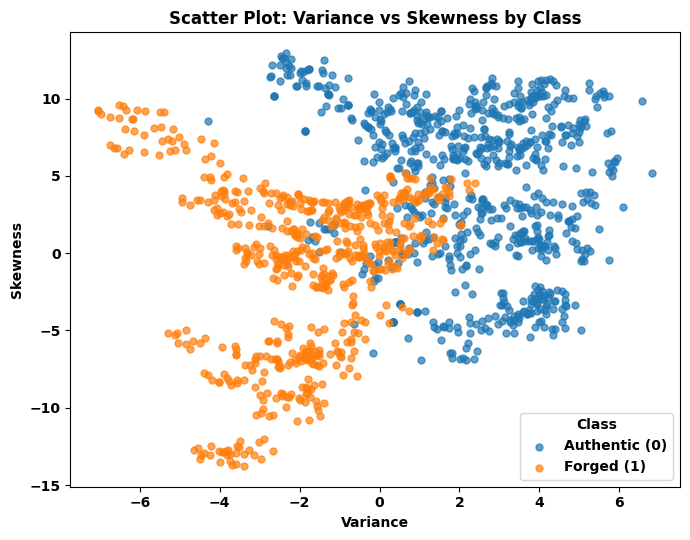

In [16]:
plt.figure(figsize=(7, 5.5))
for c in [0, 1]:
    subset = df[df["Class"] == c]
    label = "Authentic (0)" if c == 0 else "Forged (1)"
    plt.scatter(subset["Variance"], subset["Skewness"], s=25, alpha=0.7,label=label)

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Scatter Plot: Variance vs Skewness by Class")
plt.legend(title="Class", prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/scatter_plot.png", dpi=600, bbox_inches="tight")
plt.show()

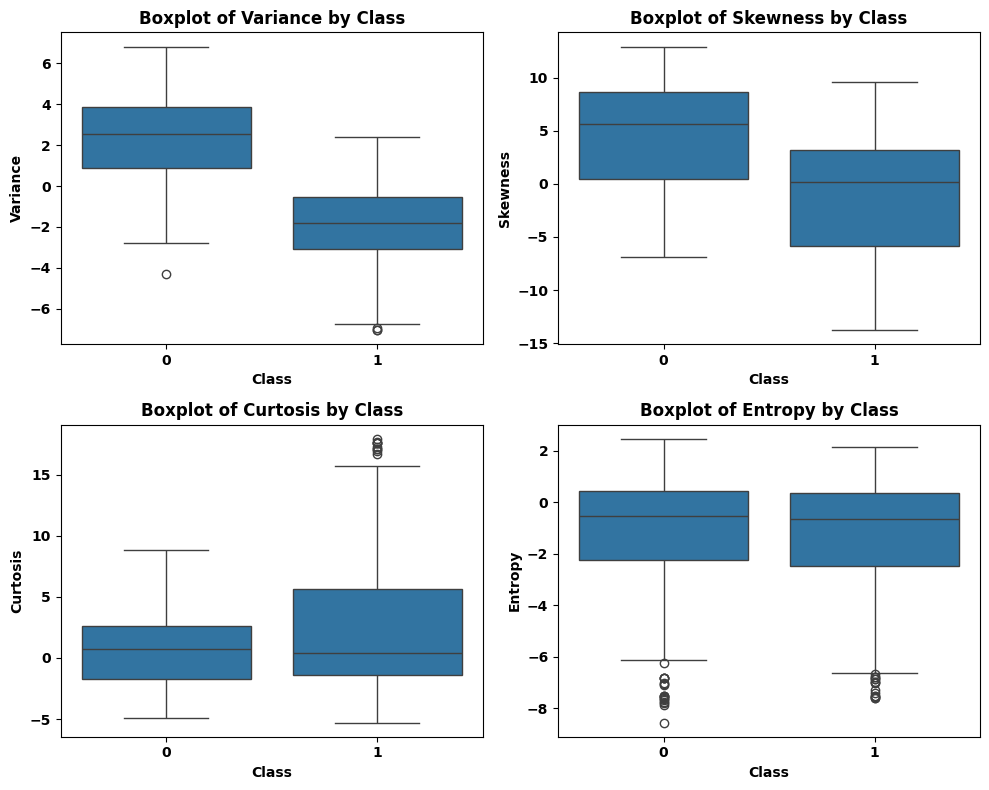

In [17]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
sns.boxplot(x="Class", y="Variance", data=df)
plt.title("Boxplot of Variance by Class")

plt.subplot(2, 2, 2)
sns.boxplot(x="Class", y="Skewness", data=df)
plt.title("Boxplot of Skewness by Class")

plt.subplot(2, 2, 3)
sns.boxplot(x="Class", y="Curtosis", data=df)
plt.title("Boxplot of Curtosis by Class")

plt.subplot(2, 2, 4)
sns.boxplot(x="Class", y="Entropy", data=df)
plt.title("Boxplot of Entropy by Class")

plt.tight_layout()
plt.savefig("plots/boxplots.png", dpi=600, bbox_inches="tight")
plt.show()

In [20]:
X = df[features].values
y = df["Class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("training samples:", X_train.shape[0])
print("testing samples :", X_test.shape[0])

training samples: 1097
testing samples : 275


In [21]:
class Perceptron:

    def __init__(self, n_features, learning_rate=0.01, epochs=50):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.epochs = epochs

        # keep track of how things change every epoch, need this for the plots later
        self.epoch_list = []
        self.error_list = []
        self.weight_list = []
        self.bias_list = []

    def step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y):
        for epoch in range(1, self.epochs + 1):
            errors = 0
            for i in range(len(X)):
                xi = X[i]
                yi = y[i]

                z = np.dot(xi, self.weights) + self.bias
                y_pred = self.step_activation(z)
                update = self.lr * (yi - y_pred)

                self.weights = self.weights + update * xi
                self.bias = self.bias + update

                if update != 0:
                    errors += 1

            self.epoch_list.append(epoch)
            self.error_list.append(errors)
            self.weight_list.append(self.weights.copy())
            self.bias_list.append(self.bias)

            print("epoch", epoch, "- errors:", errors, " weights:", self.weights, " bias:", self.bias)

    def predict(self, X):
        return self.forward(X)

In [22]:
perceptron = Perceptron(n_features=X_train.shape[1], learning_rate=0.01, epochs=50)
perceptron.fit(X_train, y_train)

epoch 1 - errors: 59  weights: [-0.06802507 -0.093809   -0.06781894 -0.01103559]  bias: -0.03
epoch 2 - errors: 25  weights: [-0.0775355  -0.1042136  -0.0810673   0.00345281]  bias: -0.04
epoch 3 - errors: 20  weights: [-0.08021271 -0.11266069 -0.09166351 -0.00362107]  bias: -0.04
epoch 4 - errors: 19  weights: [-0.08828107 -0.11959482 -0.10008104  0.00890937]  bias: -0.05
epoch 5 - errors: 20  weights: [-0.0990895  -0.12950558 -0.10372053  0.01023336]  bias: -0.05
epoch 6 - errors: 17  weights: [-0.10268335 -0.12769237 -0.11338322 -0.00095867]  bias: -0.060000000000000005
epoch 7 - errors: 24  weights: [-0.10813359 -0.13927504 -0.11084394 -0.00939311]  bias: -0.060000000000000005
epoch 8 - errors: 22  weights: [-0.11701897 -0.13568075 -0.13187689 -0.00249077]  bias: -0.060000000000000005
epoch 9 - errors: 20  weights: [-0.11755361 -0.14696013 -0.13643713 -0.00615418]  bias: -0.060000000000000005
epoch 10 - errors: 20  weights: [-0.13069073 -0.15412356 -0.12504201 -0.00600654]  bias: -

In [25]:
y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.9855
Precision: 0.9683
Recall   : 1.0
F1-Score : 0.9839


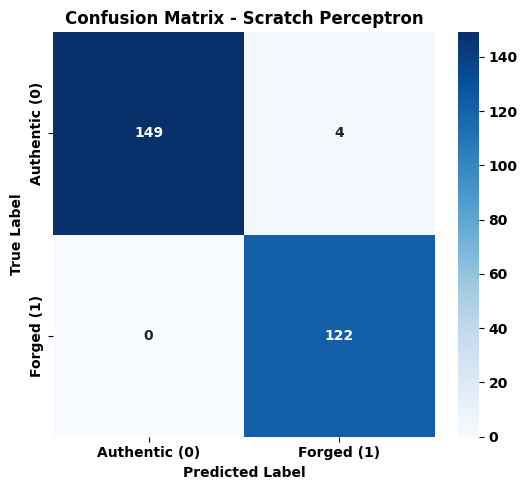

In [26]:
plt.figure(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=["Authentic (0)", "Forged (1)"],yticklabels=["Authentic (0)", "Forged (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Scratch Perceptron")
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=600, bbox_inches="tight")
plt.show()

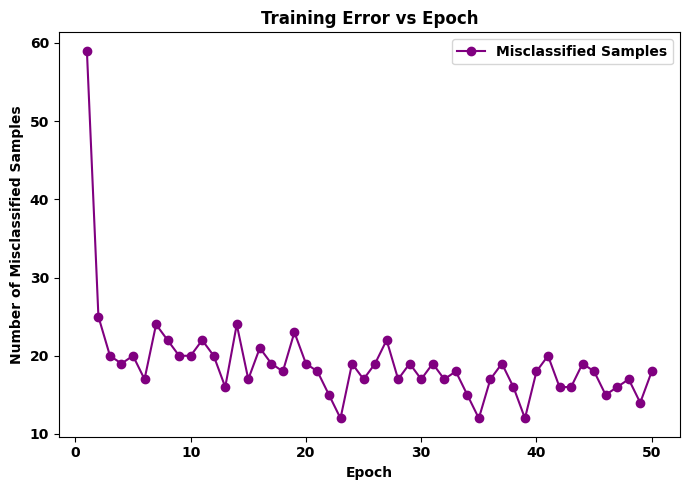

In [29]:
plt.figure(figsize=(7, 5))
plt.plot(perceptron.epoch_list, perceptron.error_list, marker="o", color="purple", label="Misclassified Samples")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.legend(prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/training_error_vs_epoch.png", dpi=600, bbox_inches="tight")
plt.show()

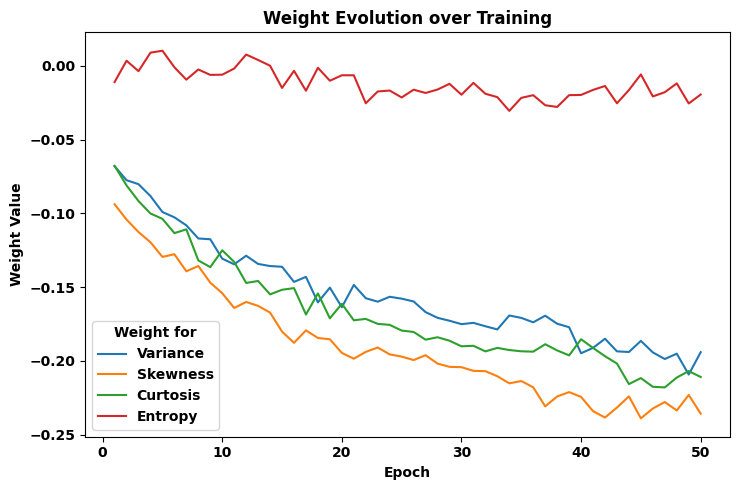

In [ ]:
plt.figure(figsize=(7.5, 5))
plt.plot(perceptron.epoch_list, perceptron.weights_array[:, 0], label="Variance")
plt.plot(perceptron.epoch_list, perceptron.weights_array[:, 1], label="Skewness")
plt.plot(perceptron.epoch_list, perceptron.weights_array[:, 2], label="Curtosis")
plt.plot(perceptron.epoch_list, perceptron.weights_array[:, 3], label="Entropy")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution over Training")
plt.legend(title="Weight for", prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/weight_evolution.png", dpi=600, bbox_inches="tight")
plt.show()

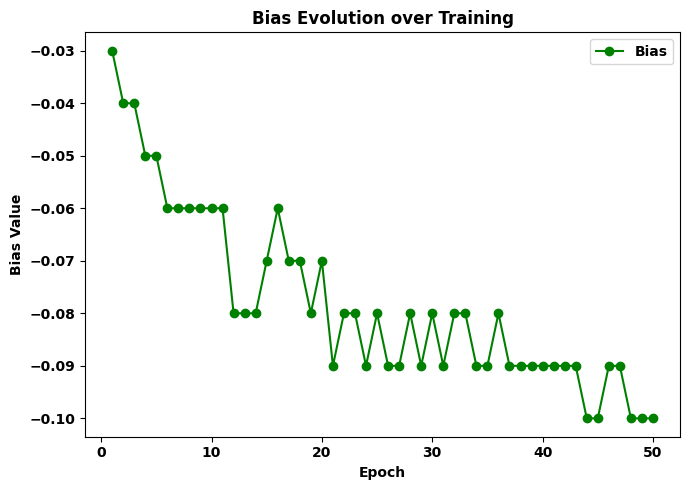

In [38]:
plt.figure(figsize=(7, 5))
plt.plot(perceptron.epoch_list, perceptron.bias_list, marker="o", color="green", label="Bias")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.title("Bias Evolution over Training")
plt.legend(prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/bias_evolution.png", dpi=600, bbox_inches="tight")
plt.show()

In [39]:
learning_rates = [0.001, 0.01, 0.1]
results_by_rate = {}

for lr in learning_rates:
    print(f"\nTraining Perceptron with learning rate: {lr}")
    model = Perceptron(n_features=X_train.shape[1], learning_rate=lr, epochs=50)
    model.fit(X_train, y_train)
    results_by_rate[lr] = model.error_list


Training Perceptron with learning rate: 0.001
epoch 1 - errors: 59  weights: [-0.00680251 -0.0093809  -0.00678189 -0.00110356]  bias: -0.003
epoch 2 - errors: 25  weights: [-0.00775355 -0.01042136 -0.00810673  0.00034528]  bias: -0.004
epoch 3 - errors: 20  weights: [-0.00802127 -0.01126607 -0.00916635 -0.00036211]  bias: -0.004
epoch 4 - errors: 19  weights: [-0.00882811 -0.01195948 -0.0100081   0.00089094]  bias: -0.005
epoch 5 - errors: 20  weights: [-0.00990895 -0.01295056 -0.01037205  0.00102334]  bias: -0.005
epoch 6 - errors: 17  weights: [-1.02683349e-02 -1.27692367e-02 -1.13383224e-02 -9.58673382e-05]  bias: -0.006
epoch 7 - errors: 24  weights: [-0.01081336 -0.0139275  -0.01108439 -0.00093931]  bias: -0.006
epoch 8 - errors: 22  weights: [-0.0117019  -0.01356807 -0.01318769 -0.00024908]  bias: -0.006
epoch 9 - errors: 20  weights: [-0.01175536 -0.01469601 -0.01364371 -0.00061542]  bias: -0.006
epoch 10 - errors: 20  weights: [-0.01306907 -0.01541236 -0.0125042  -0.00060065] 

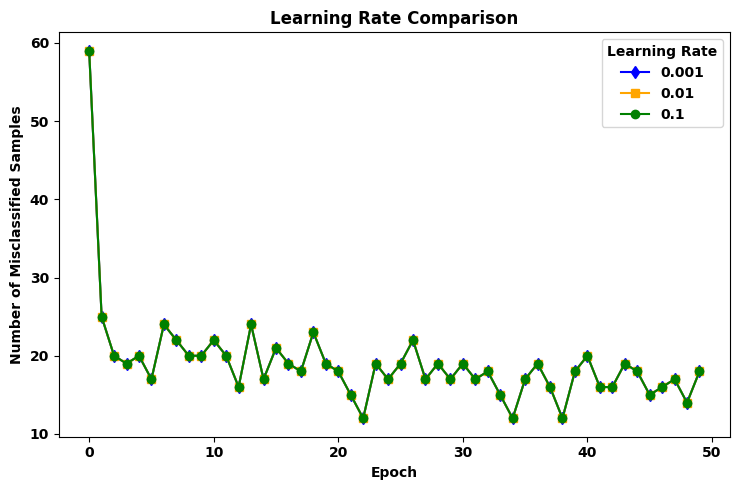

In [43]:
plt.figure(figsize=(7.5, 5))
plt.plot(results_by_rate[0.001], marker="d", color="blue", label="0.001")
plt.plot(results_by_rate[0.01], marker="s", color="orange", label="0.01")
plt.plot(results_by_rate[0.1], marker="o", color="green", label="0.1")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend(title="Learning Rate", prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/learning_rate_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

In [44]:
X_2feat = df[["Variance", "Skewness"]].values
X_2feat_scaled = StandardScaler().fit_transform(X_2feat)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2feat_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

perceptron_2d = Perceptron(n_features=2, learning_rate=0.01, epochs=50)
perceptron_2d.fit(X_train_2d, y_train_2d)

epoch 1 - errors: 196  weights: [-0.01700172 -0.01917395]  bias: 3.469446951953614e-18
epoch 2 - errors: 189  weights: [-0.02161935 -0.02232781]  bias: 0.010000000000000004
epoch 3 - errors: 193  weights: [-0.02225938 -0.02136552]  bias: 3.469446951953614e-18
epoch 4 - errors: 192  weights: [-0.01012176 -0.01543709]  bias: 3.469446951953614e-18
epoch 5 - errors: 188  weights: [-0.01080049 -0.01740926]  bias: 3.469446951953614e-18
epoch 6 - errors: 200  weights: [-0.03023505 -0.02952154]  bias: 3.469446951953614e-18
epoch 7 - errors: 190  weights: [-0.02260562 -0.02598813]  bias: 3.469446951953614e-18
epoch 8 - errors: 192  weights: [-0.01200185 -0.01824993]  bias: 3.469446951953614e-18
epoch 9 - errors: 198  weights: [-0.01833614 -0.03031325]  bias: 3.469446951953614e-18
epoch 10 - errors: 182  weights: [-0.02017761 -0.0192457 ]  bias: 3.469446951953614e-18
epoch 11 - errors: 206  weights: [-0.01954829 -0.01861479]  bias: 3.469446951953614e-18
epoch 12 - errors: 192  weights: [-0.01247

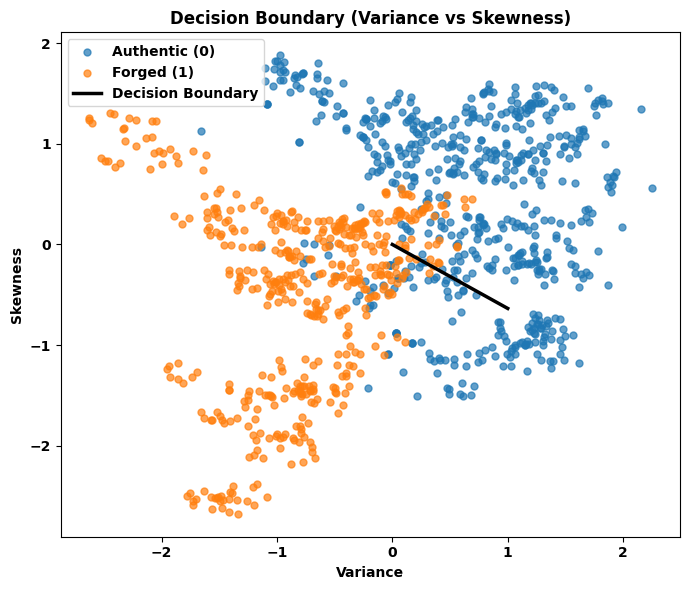

In [45]:
plt.figure(figsize=(7, 6))
for c in [0, 1]:
    mask = y_train_2d == c
    label = "Authentic (0)" if c == 0 else "Forged (1)"
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], s=25, alpha=0.7, label=label)

w1, w2 = perceptron_2d.weights
b = perceptron_2d.bias
x_vals = np.linspace(0, 1, 100)
if w2 != 0:
    y_vals = -(w1 * x_vals + b) / w2
    plt.plot(x_vals, y_vals, color="black", linewidth=2.5, label="Decision Boundary")

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Decision Boundary (Variance vs Skewness)")
plt.legend(prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/decision_boundary.png", dpi=600, bbox_inches="tight")
plt.show()

In [48]:
sk_model = SklearnPerceptron(max_iter=50, eta0=0.01, random_state=RANDOM_STATE)
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

sk_accuracy = accuracy_score(y_test, y_pred_sk)
sk_precision = precision_score(y_test, y_pred_sk)
sk_recall = recall_score(y_test, y_pred_sk)
sk_f1 = f1_score(y_test, y_pred_sk)

comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Scratch Perceptron": [accuracy, precision, recall, f1],
    "Scikit-learn Perceptron": [sk_accuracy, sk_precision, sk_recall, sk_f1],
})
comparison_table

,Metric,Scratch Perceptron,Scikit-learn Perceptron
0,Accuracy,0.985455,0.974545
1,Precision,0.968254,0.945736
2,Recall,1.000000,1.000000
3,F1-score,0.983871,0.972112


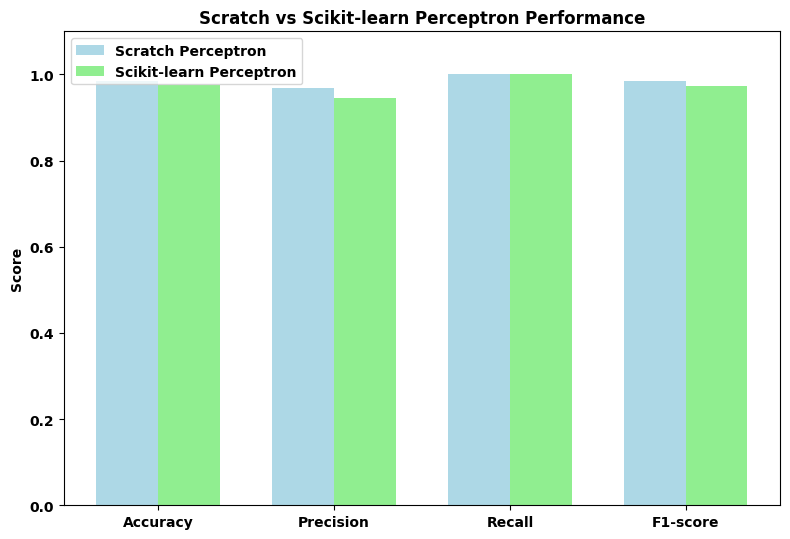

In [51]:
x_pos = np.arange(4)
bar_width = 0.35

plt.figure(figsize=(8, 5.5))
plt.bar(x_pos - bar_width/2, comparison_table["Scratch Perceptron"], bar_width,
        label="Scratch Perceptron", color="lightblue")
plt.bar(x_pos + bar_width/2, comparison_table["Scikit-learn Perceptron"], bar_width,
        label="Scikit-learn Perceptron", color="lightgreen")
plt.xticks(x_pos, comparison_table["Metric"])
plt.ylabel("Score")
plt.title("Scratch vs Scikit-learn Perceptron Performance")
plt.ylim(0, 1.1)
plt.legend(prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/sklearn_comparison.png", dpi=600, bbox_inches="tight")
plt.show()